# DATA EXPLORING

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:\Projects\sentiment social media analysis\Data\Twitter_Data.csv')

print("First 5 rows of the dataset:")
df.head()



First 5 rows of the dataset:


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [12]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [4]:
print(df['category'].value_counts())

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [5]:
print("Checking for missing values:")
df.isnull().sum()

Checking for missing values:


clean_text    4
category      7
dtype: int64

In [6]:
def load_data(filepath):
    df = pd. read_csv(filepath)

    #Handle missing values
    df=df.dropna(subset = ['clean_comment' , 'category'])

    #Convert categories to int 
    df['category'] = df['category'].astype(int)

    print(f"loaded {len(df): ,} comments")
    print(f"Columns: {df.columns.tolist()}")

    print(f"positives(1): {df[df['category']==1].shape[0]:,} ({df[df['category']==1].shape[0]/len(df)*100:1f}%)")
    print(f"positives(0): {df[df['category']==0].shape[0]:,} ({df[df['category']==0].shape[0]/len(df)*100:1f}%)")
    print(f"positives(-1): {df[df['category']==-1].shape[0]:,} ({df[df['category']==-1].shape[0]/len(df)*100:1f}%)")

    return df




# Text processing

In [7]:
def Text_processing(text):
    if not isinstance ( text ,str):
        return ""
    
    text = text.lower()

    #Remve https,www,@ and #
    text=re.sub(r"https\S+|www\S+|http\S+|@\w+|#\w+", '', text,)

    # Remove punctuation and digits (keep only letters and spaces)
    text = re.sub(r"[^a-zA-Z\s]", '', text)

    #Remove white space 
    text = re.sub(r"\S+" , '' , text).strip()

    return text 

def tokenizeNLemmatize(text):

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens  = text.split()
    for token in tokens:
        if token not in stop_words and len(token) > 2:
            lemmatized_token = lemmatizer.lemmatize(token)
    
    return ''.join(tokens)
            

# Feature Extraction

In [8]:
def extract_features(X_train, X_test, max_features=10000):
    """Convert text to TF-IDF features"""
    vectorize = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        sublinear_tf=True
    )
    
    print(f"  Fitting TF-IDF on {len(X_train):,} samples...")
    X_train_vec = vectorize.fit_transform(X_train)
    X_test_vec = vectorize.transform(X_test)
    
    print(f"  Feature matrix shape: {X_train_vec.shape}")
    return X_train_vec, X_test_vec, vectorize

# Training Model

In [9]:
def trainModels(X_train_vec, y_train):
    models = {
        'logistic_regression': LogisticRegression(max_iter=1000 , random_state= 42 , class_weight = 'balanced' , n_jobs=-1),
        'Naive_Bayes': MultinomialNB(),
        'Random_Forest': RandomForestClassifier(n_estimators=100, random_state=42 , max_depth=20 , class_weight = 'balanced' , n_jobs=-1)
    }

    trainedModels = {}
    for name , model in models.items():
        print(f" Training {name}...")
        model.fit(X_train_vec, y_train)
        trainedModels[name] = model
    return trainedModels

# Evaluate Models   

In [13]:
def evaluate_models(models, X_test, y_test):
    """Evaluate all models comprehensively"""
    results = {}

    for name, model in models.items():
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')

        print(f"\nModel: {name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score (Macro): {f1_macro:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Negative (-1)', 'Neutral (0)', 'Positive (1)']))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive']
        )
        plt.title(f'Confusion Matrix - {name}')
        plt.show()

        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'f1_macro': f1_macro
        }

    return results

  Fitting TF-IDF on 130,375 samples...
  Feature matrix shape: (130375, 10000)
 Training logistic_regression...
 Training Naive_Bayes...
 Training Random_Forest...

Model: logistic_regression
Accuracy: 0.9208
F1-Score (Macro): 0.9141

Classification Report:
               precision    recall  f1-score   support

Negative (-1)       0.86      0.88      0.87      7102
  Neutral (0)       0.91      0.97      0.94     11042
 Positive (1)       0.96      0.90      0.93     14450

     accuracy                           0.92     32594
    macro avg       0.91      0.92      0.91     32594
 weighted avg       0.92      0.92      0.92     32594



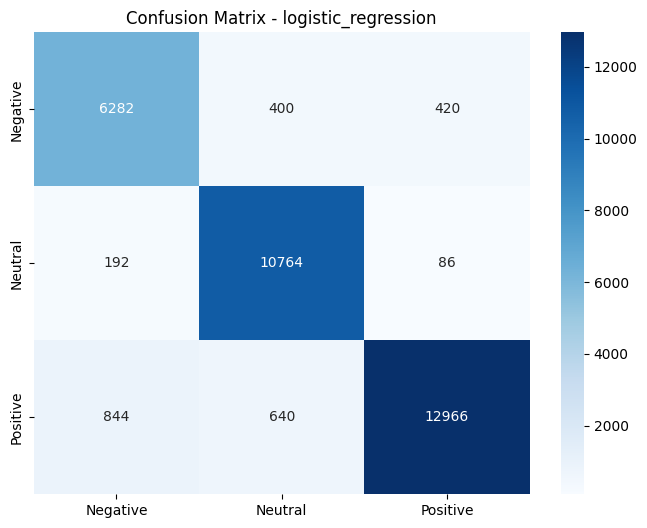


Model: Naive_Bayes
Accuracy: 0.7606
F1-Score (Macro): 0.7321

Classification Report:
               precision    recall  f1-score   support

Negative (-1)       0.84      0.49      0.62      7102
  Neutral (0)       0.85      0.73      0.78     11042
 Positive (1)       0.70      0.92      0.79     14450

     accuracy                           0.76     32594
    macro avg       0.80      0.71      0.73     32594
 weighted avg       0.78      0.76      0.75     32594



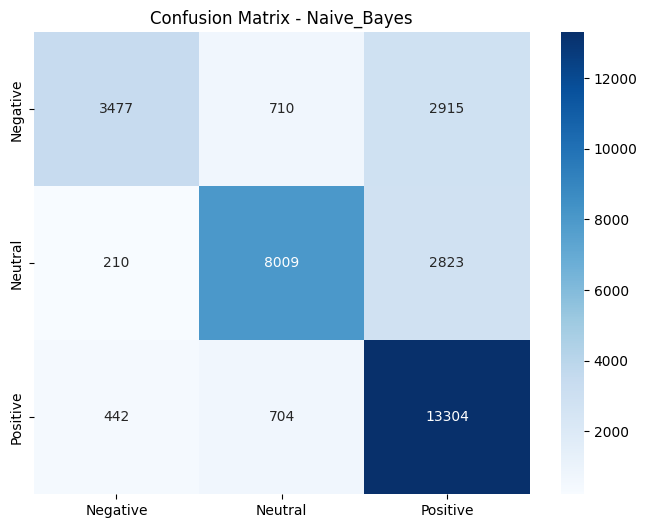


Model: Random_Forest
Accuracy: 0.7353
F1-Score (Macro): 0.7229

Classification Report:
               precision    recall  f1-score   support

Negative (-1)       0.63      0.66      0.65      7102
  Neutral (0)       0.66      0.87      0.75     11042
 Positive (1)       0.91      0.66      0.77     14450

     accuracy                           0.74     32594
    macro avg       0.73      0.73      0.72     32594
 weighted avg       0.77      0.74      0.74     32594



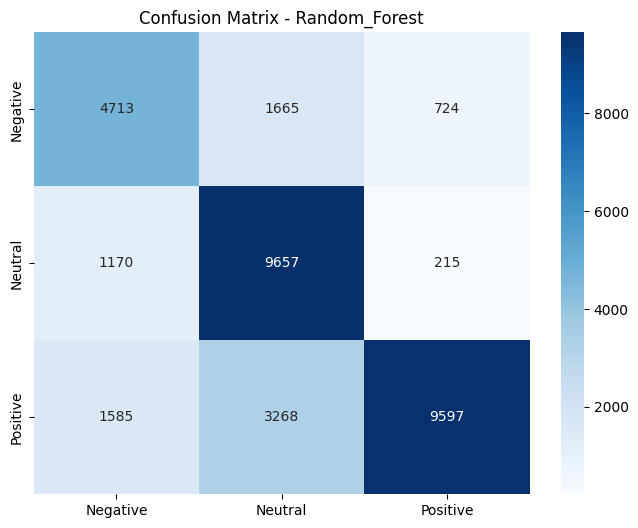


Best model: logistic_regression
Accuracy: 0.9208
F1-Macro: 0.9141


In [14]:
# Prepare data
work_df = df.dropna(subset=['clean_text', 'category']).copy()
work_df['category'] = work_df['category'].astype(int)

X = work_df['clean_text']
y = work_df['category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Extract TF-IDF features
X_train_vec, X_test_vec, vectorize = extract_features(X_train, X_test)

# Train all models
models = trainModels(X_train_vec, y_train)

# Evaluate all models
results = evaluate_models(models, X_test_vec, y_test)

# Find the best model
best_model_name = max(results, key=lambda x: results[x]['f1_macro'])
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"F1-Macro: {results[best_model_name]['f1_macro']:.4f}")

# Predict and save Model 



In [15]:
def predict_sentiment(text, model, vectorizer):
    """Predict sentiment for new text"""
    cleaned = Text_processing(text)
    processed = tokenizeNLemmatize(cleaned)
    vec = vectorizer.transform([processed])
    pred = model.predict(vec)[0]
    
    sentiment_map = {-1: '🔴 NEGATIVE', 0: '⚪ NEUTRAL', 1: '🟢 POSITIVE'}
    return sentiment_map[pred]

# Save best model
joblib.dump(best_model, 'best_sentiment_model.pkl')
joblib.dump(vectorize, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']